## Introduction to Regession with Neural Networks in TensorFlow

There are many definitions for a regression problem but in our case, we are going to simplify it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.

In [1]:
# Import TensorFlow
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1791608618.875807   25670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791608619.300091   25670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791608621.907289   25670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


### Creating data to view and fit

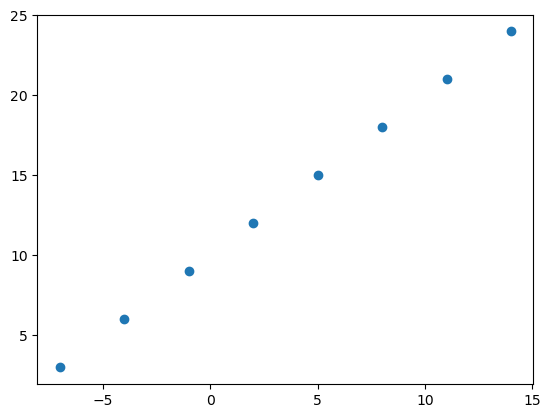

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels 
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y)

plt.show()

In [3]:
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

#### Input and Output shapes

In [4]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(['bedroom', 'bathroom', 'garage'])

house_price = tf.constant([939700])

house_info, house_price

E0000 00:00:1791608624.165382   25670 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [5]:
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [6]:
X[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [7]:
input_shape = X[0].shape
output_shape = y[0].shape

input_shape, output_shape

((), ())

In [8]:
X[0].ndim

0

In [9]:
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [10]:
#### Turn our NumPy arrays into tensors
X = tf.constant(X)
y = tf.constant(y)
X, y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [11]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

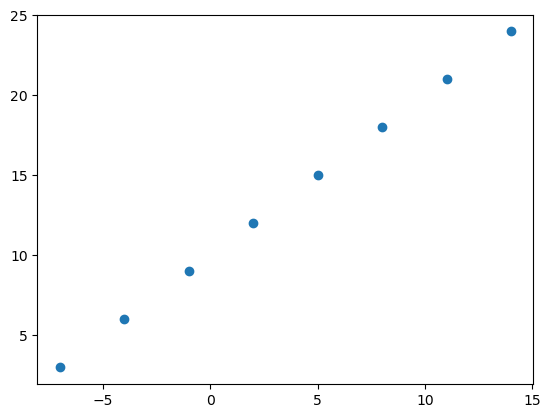

In [12]:
plt.scatter(X, y);

### Steps in Modeling with TensorFlow

1. **Creating a model** - define the input and output layers, as well as the hidden layers of a deep learning model.
2. **Compile a model** - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patterns its learning) and evaluation metrics (what we can use to interpret the peformance of our model).
3. **Fitting a model** - letting the model try to find patterns between X and y (features and labels).

In [13]:
X = tf.expand_dims(X, axis=1)
X

<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
array([[-7.],
       [-4.],
       [-1.],
       [ 2.],
       [ 5.],
       [ 8.],
       [11.],
       [14.]])>

In [14]:
# Set the random seed
tf.random.set_seed(42)

# Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss = tf.keras.losses.mae, # mae stands for mean absolute error
    optimizer = tf.keras.optimizers.SGD(), # short for stochastic gradient descent
    metrics = ['mae']
)

# 3. Fit the model
model.fit(X, y, epochs = 5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step - loss: 13.7432 - mae: 13.7432
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 13.6107 - mae: 13.6107
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 13.4782 - mae: 13.4782
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 13.3457 - mae: 13.3457
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 13.2133 - mae: 13.2133


In [15]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [16]:
# Try and make a predictiong using our model
y_pred = model.predict(np.array([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[1.8435004]], dtype=float32)

In [17]:
y_pred - 8

array([[-6.1565]], dtype=float32)

#### Improving our model

In [18]:
# Let's see if we can make another to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics = ['mae']
)

# 3. Fit the model
model.fit(X, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 13.6094 - mae: 13.6094
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 12.9083 - mae: 12.9083
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 12.1991 - mae: 12.1991
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 11.4804 - mae: 11.4804
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 10.7499 - mae: 10.7499
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 10.0056 - mae: 10.0056
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 9.2458 - mae: 9.2458
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 8.4692 - mae: 8.4692
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 7.6743 - mae: 7.6743
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 6.8596 - mae: 6.8596
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 6.7149 - mae: 6.7149
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 7.0696 - mae: 7.0696
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━

In [19]:
# Let's remind ourselves of the data
X, y

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [20]:
# Let's try to make a prediction
model.predict(np.array([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


array([[25.636381]], dtype=float32)

#### Evaluating a model

In practice, a typical workflow you will go through when building neural networks is :

```
Build a model -> Fit the model -> Evaluate it -> Tweak a model -> fit it -> Evaluate it -> tweak the model
```

When it comes to evaluation... there are 3 words you should memorize:

> "Visualize, Visualize, Visualize"

It's a good idea to visualize:
* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the ground truth (the original labels)?

In [21]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [22]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

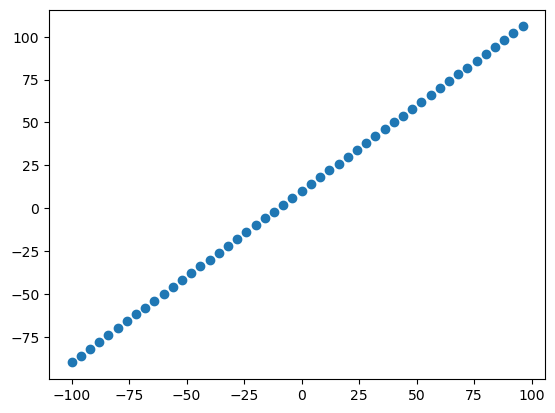

In [23]:
# Visualize the data
import matplotlib.pyplot as plt

plt.scatter(X, y)

### The 3 sets ...

* **Training set** - the model learns from this data, which is typically 70-80% of the total data you have available.
* **Validation set** -  the model gets tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what it has learned, this set is typically 10-15% of the total data available.

In [24]:
# Check the length of how many samples we have 
len(X)

50

In [25]:
# Split the data into train and test sets
X_train = X[:40] # First 40 are training samples (80% of the data)
y_train = y[:40]
X_test = X[40:] # last 10 are testing samples  (20% of the data)
y_test = y[40:]

X_train, X_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([60, 64, 68, 72, 76, 80, 84, 88, 92, 96], dtype=int32)>)

In [26]:
y_train, y_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

#### Visualizing the data

Now we have got our data in training and test sets... let's visualiza it again!

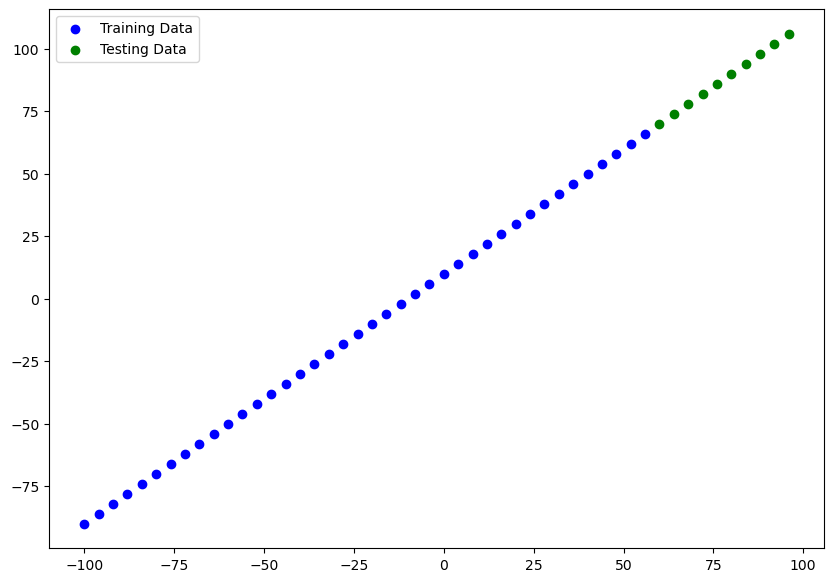

In [27]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c='b', label='Training Data') # our model will learn on this
# Plot test data in green
plt.scatter(X_test, y_test, c='g', label='Testing Data') # want our model to be able to predict this (given X, what's y?)
# Show a legend
plt.legend()
plt.show()

In [28]:
# Let's have a look at how to build a neural network for our data

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.SGD(),
             metrics=['mae'])

# 3. Fit the model
# model.fit(X_train, y_train, epochs=100)

#### Visualizing the model

In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
X_train[0], y_train[0]

(<tf.Tensor: shape=(), dtype=int32, numpy=-100>,
 <tf.Tensor: shape=(), dtype=int32, numpy=-90>)

In [31]:
X_train.shape, y_train.shape

(TensorShape([40]), TensorShape([40]))

In [32]:
# Let's create a model which builds automatically by defining the input shape argument in the first layer
tf.random.set_seed(42)

# 1. Create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name='input_layer'),
    tf.keras.layers.Dense(1, name='output_layer')
], name='model_1')

# 2. Compile the model (same as above)
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

/home/aditya/miniconda3/envs/tfenv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

* Total params - Total number of parameters in the model.
* Trainable parameters - These are the parameters (patterns) that the model can update as it trains.
* Non-trainable parameters - These parameters are not updated during training (this is typical when you bring in already learnt patterns or parameters from other models during **transfer learning**)

📖 **Resource:** For a more in-depth overview of trainable parameters within a layer, check out MIT's introduction to deep learning video: https://introtodeeplearning.com/

In [34]:
# Let's fit our model to the training data
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 35.5856 - mae: 35.5856 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 22.2890 - mae: 22.2890
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 14.5206 - mae: 14.5206
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 18.6076 - mae: 18.6076
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 13.5593 - mae: 13.5593
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 15.1498 - mae: 15.1498
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 15.6243 - mae: 15.6243
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 12.1908 - mae: 12.1908
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 14.7237 - mae: 14.7237
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 15.5198 - mae: 15.5198
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 12.2858 - mae: 12.2858
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.8859 - mae: 14.8859
Epoch 13/100
2/2 ━━━━━━━

In [35]:
# Get a summary of our model 
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

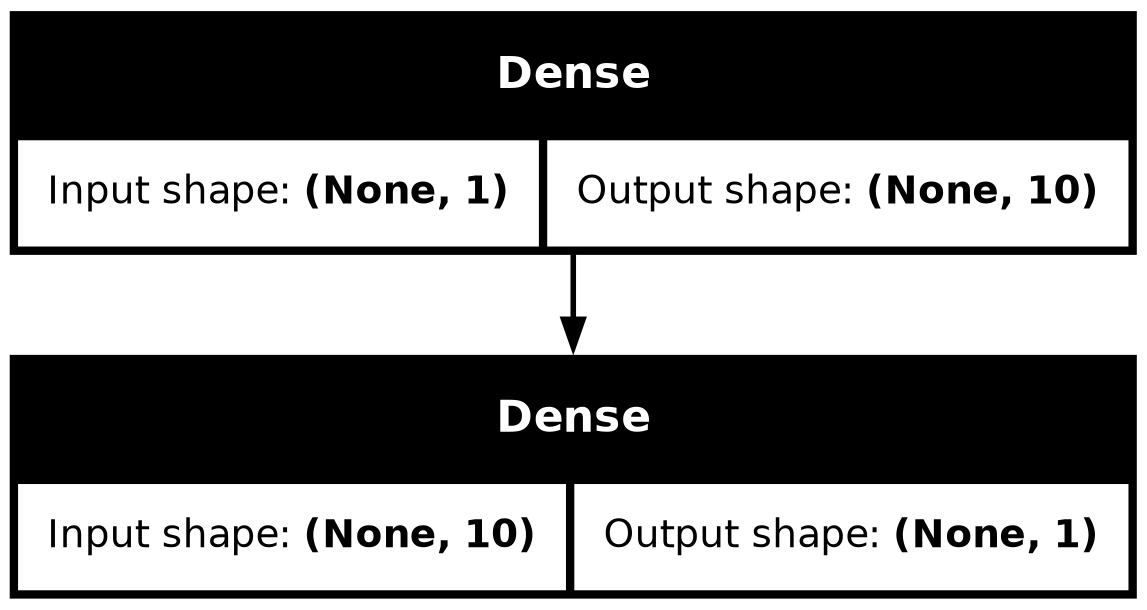

In [36]:
from tensorflow.keras.utils import plot_model 

plot_model(model=model, show_shapes=True)

#### Visualizing our model's predictions

To visualize predictions, it's a good idea to plot them against the ground truth labels.

Often you will see this in the form of `y_test` or `y_true` versus `y_pred` (ground truth versus your model's predictions).

In [37]:
# Make some predictions
y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


array([[41.76959 ],
       [44.44398 ],
       [47.118374],
       [49.792767],
       [52.467163],
       [55.14156 ],
       [57.815952],
       [60.490345],
       [63.164738],
       [65.83914 ]], dtype=float32)

In [38]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

🔑 **Note:** If you feel like you are going to reuse some kind of funtionality in the future, it's a good idea to turn it into a function.

In [39]:
# Let's create a plotting function
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_pred):
    '''
    Plots training data, test data and compares predictions to ground truth labels.
    '''
    plt.figure(figsize=(10, 7))
    
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', label='Training Data')

    # Plot testing data in green
    plt.scatter(test_data, test_labels, c='g', label='Testing Data')

    # Plot model's predictions in red
    plt.scatter(test_data, predictions, c='r', label='Predictions')

    # Show the legend
    plt.legend();

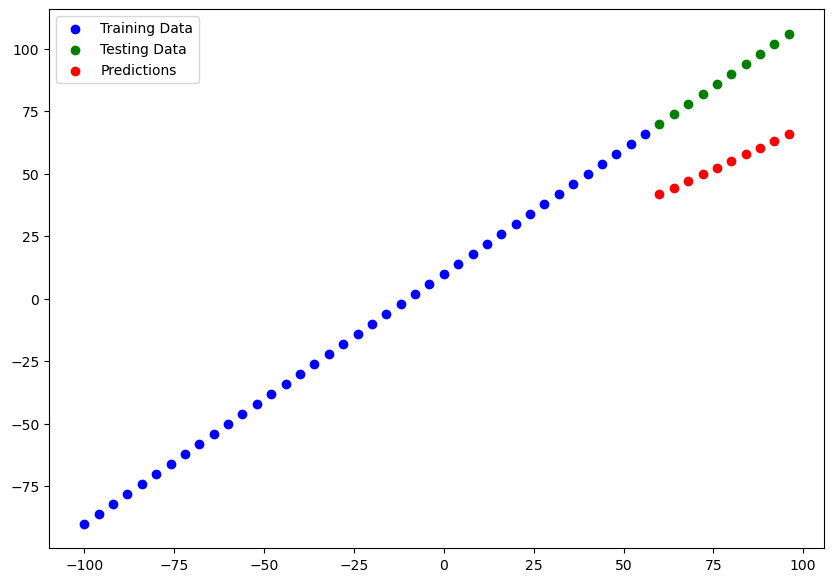

In [40]:
plot_predictions(
    train_data = X_train,
    train_labels = y_train,
    test_data = X_test,
    test_labels = y_test,
    predictions = y_pred
)

#### Evaluating our model's predictions with regression evaluation metrics

Depending on the problem you are working on, there will be different evaluation metrics to evaluate your model's performance.

Since we are working on a regression problem, two of the main metrics:

* MAE - mean absolute error, "on average, how wrong is each of my model's predictions"
* MSE - mean squared error, "square the average errors"

In [41]:
# Evaluate the model on the test
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 34.1956 - mae: 34.1956


[34.195640563964844, 34.195640563964844]

In [42]:
y_pred = np.squeeze(y_pred)
y_pred

array([41.76959 , 44.44398 , 47.118374, 49.792767, 52.467163, 55.14156 ,
       57.815952, 60.490345, 63.164738, 65.83914 ], dtype=float32)

In [43]:
y_test.numpy().astype(float)

array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.])

In [44]:
# Calculate the mean absolute error
mae = tf.keras.metrics.MeanAbsoluteError()
mae.update_state(y_test, y_pred)
mae.result()

<tf.Tensor: shape=(), dtype=float32, numpy=34.195640563964844>

In [45]:
y_test - y_pred

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([29, 30, 31, 33, 34, 35, 37, 38, 39, 41], dtype=int32)>

In [46]:
y_pred - y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([-29, -30, -31, -33, -34, -35, -37, -38, -39, -41], dtype=int32)>

In [47]:
# Calculate the mean squared error
mse = tf.metrics.MeanSquaredError()
mse.update_state(y_test, y_pred)
mse.result()

<tf.Tensor: shape=(), dtype=float32, numpy=1183.8388671875>

In [48]:
# Make some functions to reuse MAE and MSE
def mae(y_true, y_pred):
    mae = tf.metrics.MeanAbsoluteError()
    mae.update_state(y_true, y_pred)
    return mae.result()

def mse(y_true, y_pred):
    mse = tf.metrics.MeanSquaredError()
    mse.update_state(y_true, y_pred)
    return mse.result()

### Running Experiments to Improve our Model

```
Build a Model -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it......
```

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).

2. Make your model larger (using a more complex model) - this might come in the form of more layers or more hidden units in each layer.

3. Train for longer - give your model more of a chance to find patterns in the data.

Let's do three modelling experiments:

1. `model_1` - same as the original model, 1 layer, trained for 100 epochs.

2. `model_2` - two layers, trained for 100 epochs.

3. `model_3` - three layers, trained for 500 epochs.

**Build `model_1`**

In [49]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model 
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

# 2. Compile the model 
model_1.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# 3. Fit the model
model_1.fit(X_train, y_train, epochs=100)

/home/aditya/miniconda3/envs/tfenv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 90.6502 - mae: 90.6502 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 55.8747 - mae: 55.8747
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 21.9613 - mae: 21.9613
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.7560 - mae: 11.7560
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 12.6124 - mae: 12.6124
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.4248 - mae: 8.4248
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.1000 - mae: 9.1000
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.9281 - mae: 7.9281
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.8788 - mae: 10.8788
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.6773 - mae: 7.6773
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.9297 - mae: 11.9297
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.3468 - mae: 8.3468
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


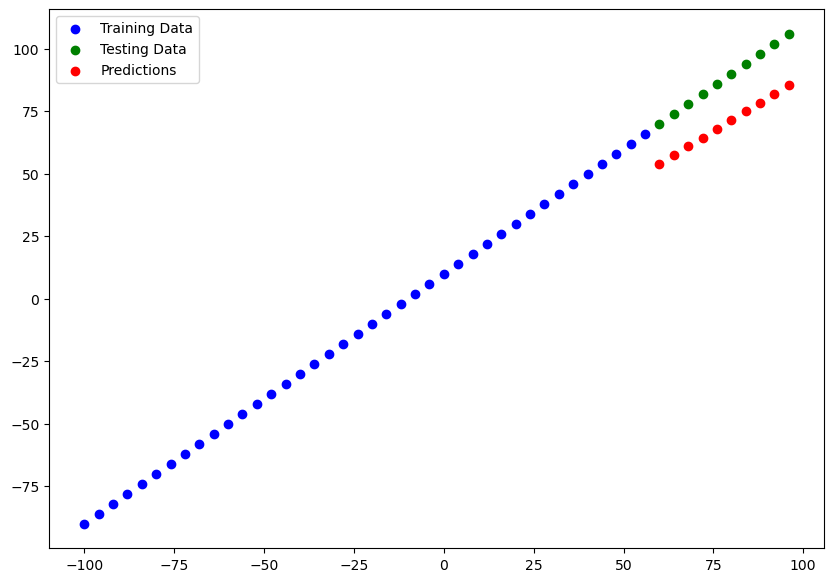

In [50]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [51]:
# Calculate model_1 evaluation metrics
mae_1 = mae(y_test, y_preds_1)
mse_1 = mse(y_test, y_preds_1)
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=18.268014907836914>,
 <tf.Tensor: shape=(), dtype=float32, numpy=335.74127197265625>)

**Build `model_2`**

* Two dense layers, trained for 100 epochs

In [52]:
X_train = tf.expand_dims(X_train, axis=-1)
X_train.shape

TensorShape([40, 1])

In [53]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics = ['mse']
)

# 3. Fit the model
model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 76.6516 - mse: 9139.0625  
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 34.2638 - mse: 1703.0746
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 12.0815 - mse: 201.4301
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 17.3121 - mse: 442.7414
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 11.5802 - mse: 163.0653
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 12.6726 - mse: 192.5921
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 14.6350 - mse: 296.7841
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.8767 - mse: 161.9041
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 12.8396 - mse: 205.3669
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 15.1582 - mse: 324.6167
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 10.6980 - mse: 136.4529
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 11.5447 - mse: 151.0192 
Epoch 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


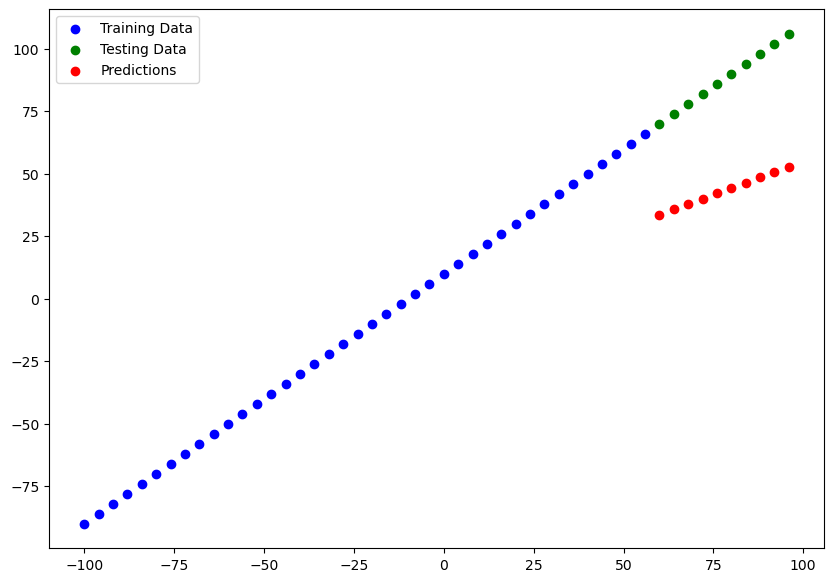

In [54]:
# Make and plot predictions of model_2
y_preds_2 = model_2.predict(X_test)

plot_predictions(predictions=y_preds_2)

In [55]:
# Calculate model_2 evaluation metrics
mae_2 = mae(y_test, y_preds_2)
mae_2

<tf.Tensor: shape=(), dtype=float32, numpy=44.73759460449219>

In [56]:
mse_2 = mse(y_test, y_preds_2)
mse_2

<tf.Tensor: shape=(), dtype=float32, numpy=2030.514892578125>

**Build `model_3`**

* 2 layers, trained for 500 epochs

In [57]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss = tf.keras.losses.mae,
               optimizer = tf.keras.optimizers.SGD(),
               metrics=['mae'])

# 3. Fit the model
model_3.fit(X_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 36.5434 - mae: 36.5434 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 28.4985 - mae: 28.4985
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 21.6234 - mae: 21.6234
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 18.4997 - mae: 18.4997
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16.7486 - mae: 16.7486
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16.6362 - mae: 16.6362
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 16.4906 - mae: 16.4906
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 12.3764 - mae: 12.3764
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 14.8931 - mae: 14.8931
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.6479 - mae: 15.6479
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.3656 - mae: 12.3656
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14.9718 - mae: 14.9718
Epoch 13/500
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


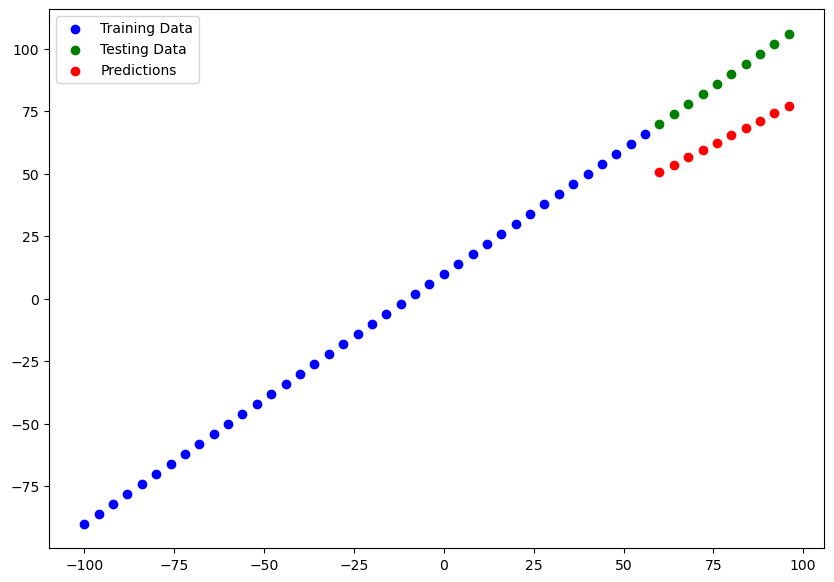

In [58]:
# Make and plot some predictions
y_preds_3 = model_3.predict(X_test)

plot_predictions(predictions=y_preds_3)

In [59]:
# Calculate model_3 evaluation metrics
mse_3 = mse(y_test, y_preds_3)
mae_3 = mae(y_test, y_preds_3)

mse_3, mae_3

(<tf.Tensor: shape=(), dtype=float32, numpy=587.1830444335938>,
 <tf.Tensor: shape=(), dtype=float32, numpy=24.039188385009766>)

🔑 **Note:** You want to start with small experiments (small models) and make sure they work and then increase their scale when necessary.

#### Comparing the results of our experiments

We have run a few experiments now, let's compare the results.

In [61]:
# Let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [["model_1", mae_1.numpy(), mse_1.numpy()],
                ["model_2", mae_2.numpy(), mse_2.numpy()],
                ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,18.268015,335.741272
1,model_2,44.737595,2030.514893
2,model_3,24.039188,587.183044


Looks like `model_2` performed the best...

In [62]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

> 🔑 **Note:** One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you will figure out which do not work and in turn, get close to figuring out what does work. Remember the machine learning practitioner's motto: "experiment, experiment, experiment".

#### Tracking your experiments

One really good habit in machine learning modelling is to track the results of your experiments.

And when doing so, it can be tedious if you are running lots of experiments.

Luckily, there are tools to help us!

📖 **Resource:** As you build more models, you will want to look into using:

* TensorBoard - a component of the TensorFlow library to help track modelling experiments (we will see this one later).
* Weights and Biases - a tool for tracking all kinds of machine learning experiments (plugs straight into TensorBoard).